In [1]:
"""
Burst_modeling.ipynb
Lukasz Radzinski
Charite Neurophysics Group, Berlin
Script for simulating sigma burst
statistical properties
"""

'\nBurst_modeling.ipynb\nLukasz Radzinski\nCharite Neurophysics Group, Berlin\nScript for simulating sigma burst\nstatistical properties\n'

In [2]:
import os
import meet
import scipy
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig
from BurstModel import BurstModel
import matplotlib.ticker as plticker


# set global parameters for plots

plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['axes.autolimit_mode'] = 'round_numbers'
plt.rcParams['axes.ymargin'] = 0.01
plt.rcParams['axes.xmargin'] = 0.01

2026-02-06 12:33:42.405693: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-06 12:33:43.059924: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# general settings

# select subject [S1-S5]
subject = 'S1'

additional_file_info = ''
additional_title_info = ''

data_input_folder = '../Data/cleaned_data'
plots_output_folder = '../Results/burst_modeling'

additional_plot_title = ''

srate = 20000

meg_unit = 'B [fT]'
meg_asd_unit = '[fT/√Hz]'

In [4]:
data_input_folder = os.path.join(data_input_folder)
plots_output_folder = os.path.join(plots_output_folder, subject)

In [5]:
# add header to the plot
def plt_header(main_title='', use_suptitle = False, fontsize=12):

    title = subject+', MEG'+additional_title_info
    title += '\n'+main_title+additional_plot_title
    
    if(use_suptitle):
        plt.suptitle(title, fontsize=fontsize)
    else:
        plt.title(title, fontsize=fontsize)

In [6]:
# show and save the plot
def plt_show_save_fig(fig_name=None):

    if(fig_name):
        fig_name += '.png'
    else:
        plt_show_save_fig.counter += 1
        fig_name = subject+'_fig%02d.png' % plt_show_save_fig.counter

    print('--------------------\n'+fig_name)
    os.makedirs(plots_output_folder, exist_ok=True)
    plt.savefig(os.path.join(plots_output_folder, fig_name), bbox_inches='tight')
    plt.show()

plt_show_save_fig.counter = 0

In [7]:
# load MEG and marker data

meeg_data_file = os.path.join(data_input_folder, subject+'.npy')
meeg_stim_data = np.load(meeg_data_file)

meg_data = meeg_stim_data[0]
marker = meet.getMarker(meeg_stim_data[-1])

In [8]:
# set bandpass frequency range adjusted for every subject

if(subject == 'S1' or subject == 'S2'):
    sigma_lfreq = 450
    sigma_rfreq = 850
elif(subject == 'S3' or  subject == 'S4' or subject == 'S5'):
    sigma_lfreq = 500
    sigma_rfreq = 900


sigma_freq_range_str = '%sHz-%sHz' % (sigma_lfreq, sigma_rfreq)

meg_data_hilb = sig.hilbert(meg_data)

# FIR filter

sigma_fir_coeffs = sig.firwin(303, [sigma_lfreq, sigma_rfreq], pass_zero=False, fs=srate)
meg_sigma_data_hilb = sig.filtfilt(sigma_fir_coeffs, 1.0, meg_data_hilb)

In [9]:
# set sigma burst time window adjusted for every subject

if(subject == 'S1'):
    burst_win_ms = [13, 33]
elif(subject == 'S2'):
    burst_win_ms = [13, 28]
elif(subject == 'S3'):
    burst_win_ms = [13, 28]
elif(subject == 'S4'):
    burst_win_ms = [13, 25]
elif(subject == 'S5'):
    burst_win_ms = [10, 30]

In [10]:
# extract trials

burst_win_samples = np.round(np.array(burst_win_ms)/1000.*srate).astype(int)
sigma_burst_trials = meet.epochEEG(meg_sigma_data_hilb, marker, burst_win_samples)
data_t_burst_ms = np.linspace(burst_win_ms[0], burst_win_ms[1], sigma_burst_trials.shape[-2]+1)[:-1]

medium_win_ms = [0, 80]
medium_win_samples = np.round(np.array(medium_win_ms)/1000.*srate).astype(int)
sigma_medium_trials = meet.epochEEG(meg_sigma_data_hilb, marker, medium_win_samples)
data_t_medium_ms = np.linspace(medium_win_ms[0], medium_win_ms[1], sigma_medium_trials.shape[-2]+1)[:-1]

In [11]:
# calculate indices in medium trials that correspond to the sigma burst time window

burst_mt_smpl = [np.nonzero(data_t_medium_ms == burst_win_ms[0])[0][0],
              np.nonzero(data_t_medium_ms == burst_win_ms[1])[0][0]]
burst_mt_smpl = np.array(burst_mt_smpl)

# set simulated burst offset position in relation the physiological burst
sigma_sim_offset_ms = 30
burst_sim_mt_smpl = np.array(burst_mt_smpl)+sigma_sim_offset_ms*srate//1000
data_t_burst_sim_ms = data_t_burst_ms + sigma_sim_offset_ms

In [12]:
# calculate evoked response
# use Tukey window to taper the edges

evoked_response_raw = (sigma_burst_trials.mean(-1))
tukey_win = sig.windows.tukey(len(evoked_response_raw), 0.2)
evoked_response_tuk = evoked_response_raw * tukey_win
evoked_response = evoked_response_tuk

--------------------
Evoked response.png


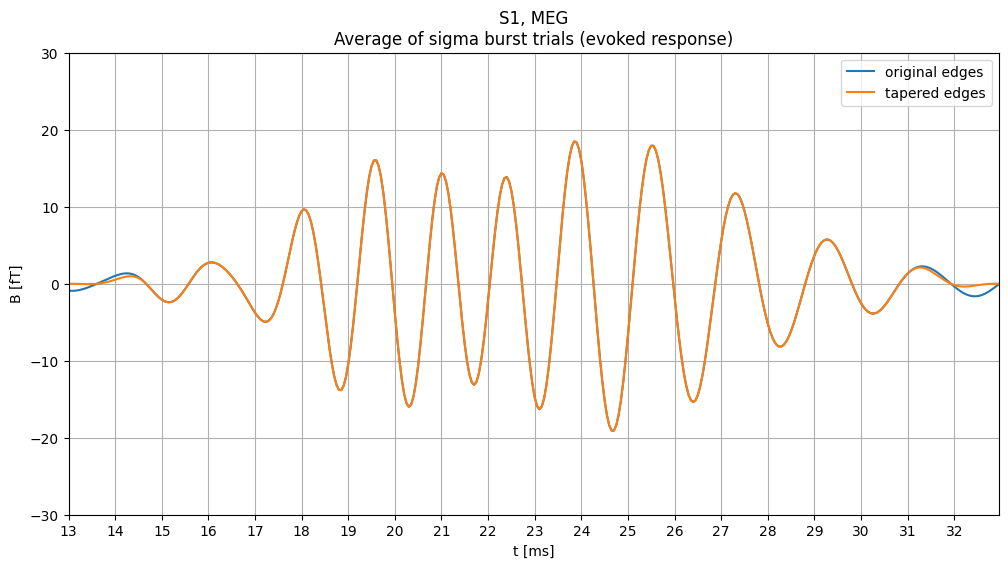

In [13]:
# plot sigma burst evoked response and edges tapered by Tukey window 

fig, ax = plt.subplots()
plt_header('Average of sigma burst trials (evoked response)')
data_y = evoked_response_raw.real
data_t = data_t_burst_ms
ax.plot(data_t, data_y, label='original edges')

data_y = evoked_response_tuk.real
ax.plot(data_t, data_y, label='tapered edges')

ax.set_xlabel('t [ms]')
ax.set_ylabel(meg_unit)
vmax=30
ax.set_ylim((-vmax,vmax))
ax.set_xlim((data_t[0], data_t[-1]))
ax.xaxis.set_major_locator(plticker.MultipleLocator(1))
ax.grid()
ax.legend()
plt_show_save_fig('Evoked response')

In [14]:
def plot_loss_results(burst_model, sigma_sim_medium_trials, is_test_set=False, filename=None):

    fig, axs = plt.subplots(2, 2, figsize=(16, 9))

    loss_result = burst_model.calculate_model_loss(sigma_sim_medium_trials, is_full_output=True)
    data_t = data_t_burst_ms

    for k in range(4):

        if(k == 0):
            i,j=0,0
            subtitle='Avg(trials)'
        elif(k == 1):
            i,j=1,0
            subtitle='Std(trials)'
        elif(k == 2):
            i,j=0,1
            subtitle='Avg(Env(trials))'
        elif(k == 3):
            i,j=1,1
            subtitle='Std(Env(trials))'

        data_y_phys_norm = loss_result[k][0]
        data_y_sim_norm = loss_result[k][1]
        data_y_phys_std = loss_result[k][2]
        data_y_phys_min = loss_result[k][3]

        axs[i][j].plot(data_t, data_y_phys_norm, linewidth=1, label='physiological burst')
        axs[i][j].plot(data_t, data_y_sim_norm, linewidth=1, label='simulated burst')
        axs[i][j].xaxis.set_major_locator(plticker.MultipleLocator(5))
        axs[i][j].set_xticks(np.sort(np.concatenate([axs[i][j].get_xticks(), burst_win_ms])))
        axs[i][j].set_xlim(burst_win_ms)
        if(k==0):
            axs[i][j].set_ylim(-4,4)
        else:
            axs[i][j].set_ylim(0,4)
        axs[i][j].set_ylabel('normalized unit')
        if(i==1):
            axs[i][j].set_xlabel('t [ms]')
        axs[i][j].grid(linewidth=0.5)
        axs[i][j].legend(loc='upper left')
        loss = loss_result[-1][k]
        axs[i][j].set_title(subtitle+', loss=%.3f' % loss)
        axs2 = axs[i][j].twinx()
        physical_ticks = axs[i][j].get_yticks() * data_y_phys_std
        physical_ticks = physical_ticks + data_y_phys_min
        axs2.set_ylim((physical_ticks[0], physical_ticks[-1]))
        axs2.set_yticks(physical_ticks)
        axs2.yaxis.set_major_formatter(plticker.FormatStrFormatter('%4.1f'))
        axs2.set_ylabel(meg_unit)

    if(is_test_set):
        txt='test set'
    else:
        txt='train set'

    if(filename):
        title = filename.split('/')[-1]
    else:
        title = subject
    plt.suptitle(title+'\nFit between simulated and physiological burst, %s, total loss=%.3f'
            % (txt, loss_result[-1][-1]), fontsize=14)
    fig.tight_layout()
    plt_show_save_fig(filename)

In [15]:
import pandas as pd

df_out = pd.DataFrame({
    'subject':[],
    'fold':[],
    'opt_params':[],
    'div_steep':[],
    'div_offset':[],
    'ecavs':[],
    'eclvs':[],
    'lcavs':[],
    'lclvs':[],
    'train_loss':[],
    'test_loss':[]
})

(10, 0, 0, 0, 0, 0)
2.7135872858079657
--------------------
f0/S1_f0_p0_div_curve.png


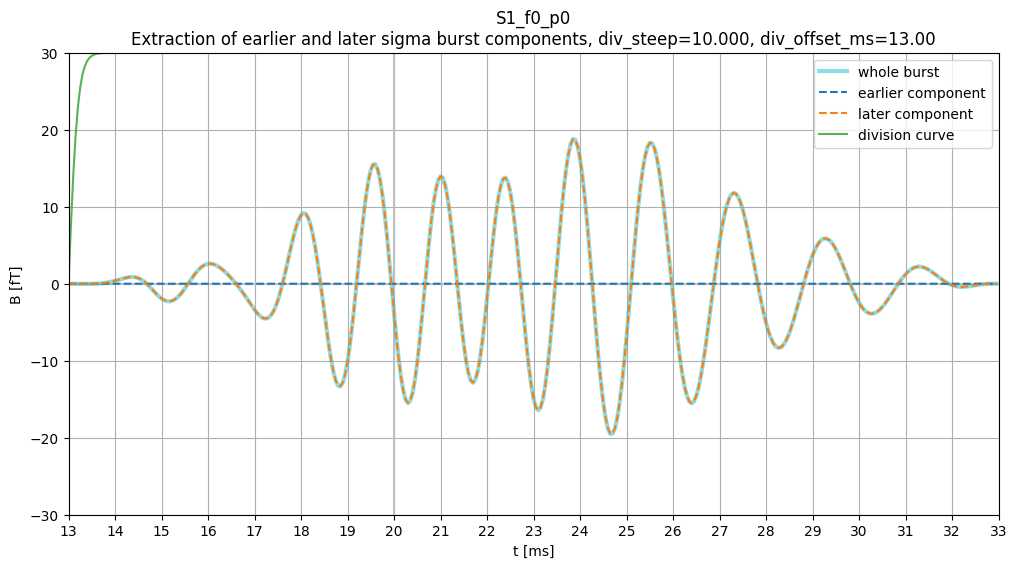

--------------------
f0/S1_f0_p0_train_set_loss.png


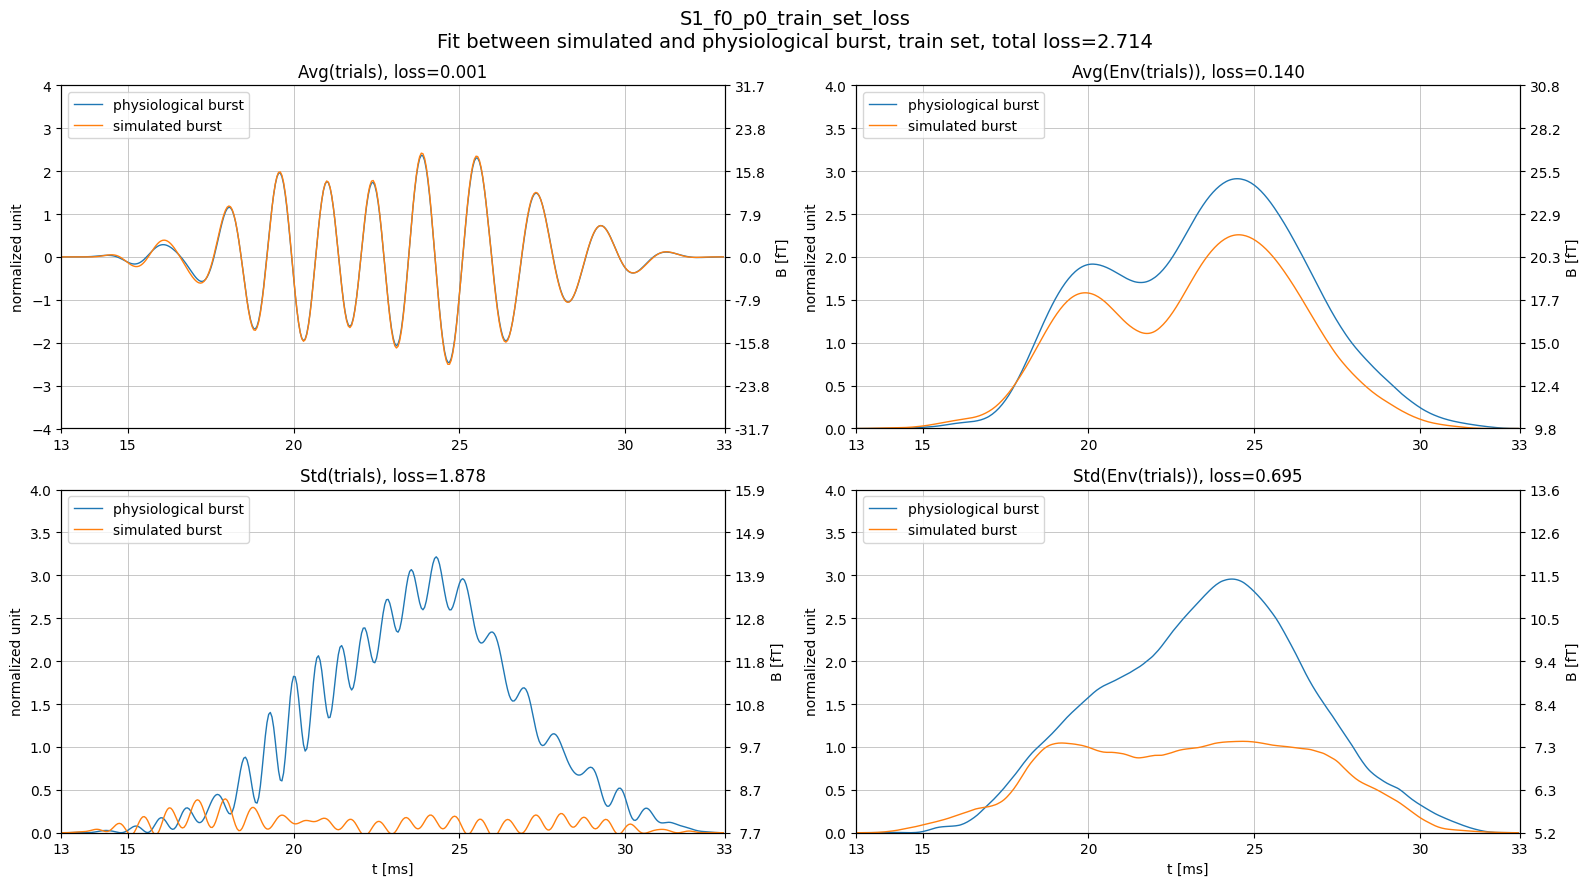

--------------------
f0/S1_f0_p0_test_set_loss.png


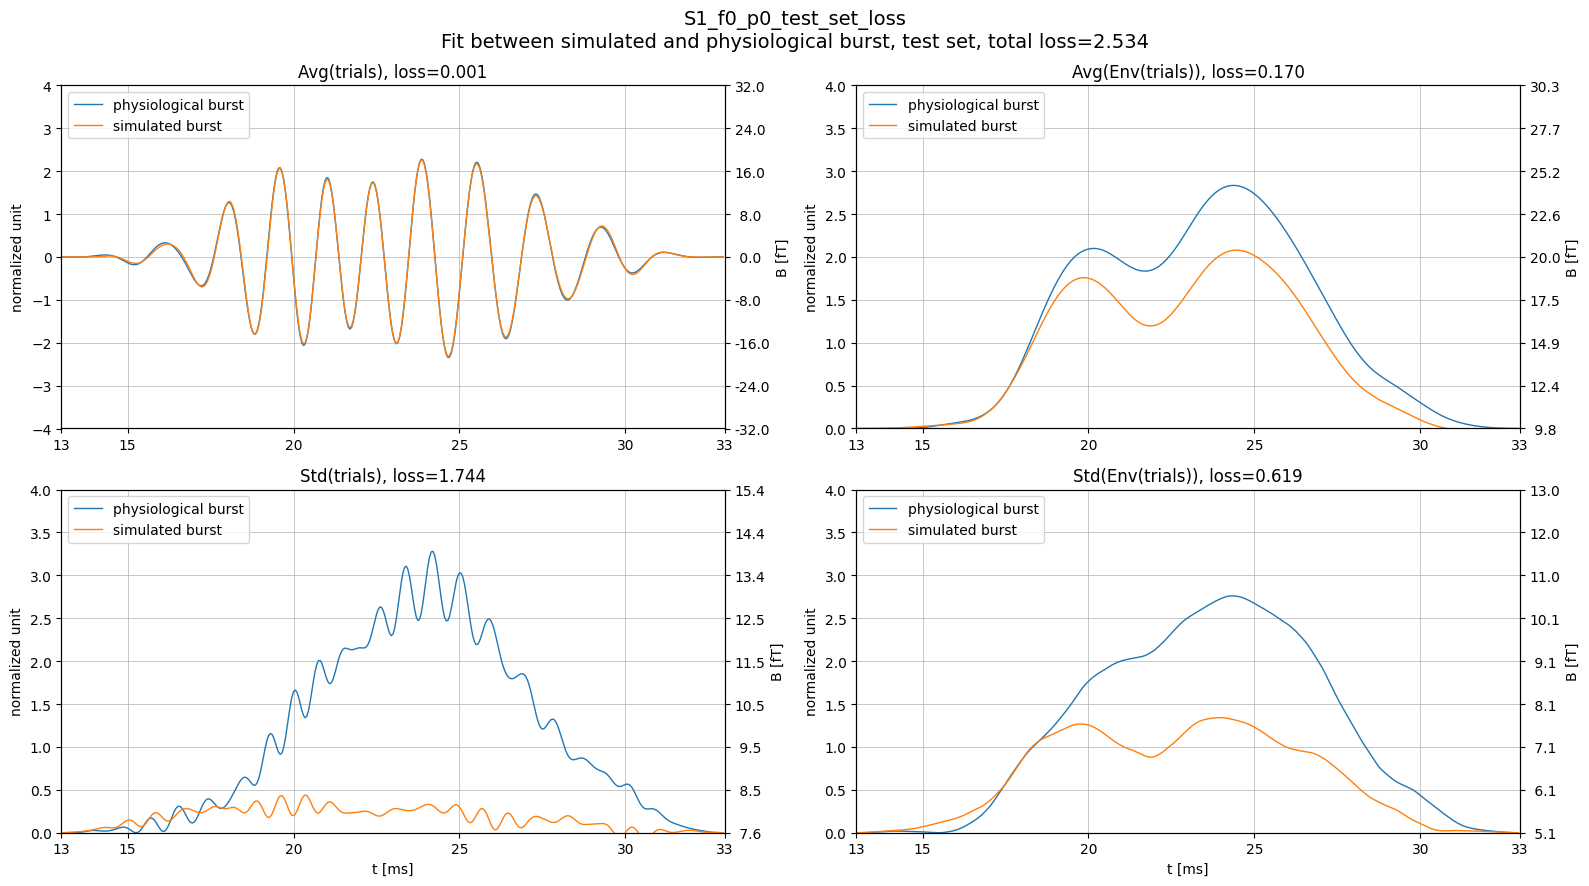

2.5339556776158654
run: 0, iter : 0
 fun: 0.6672893036910525
   x: [ 1.000e+01  4.221e-11  7.253e-11  9.766e-12  3.412e-01  3.982e+00]
run: 0, iter : 1
 fun: 0.5157090610728176
   x: [ 1.000e+01  0.000e+00  7.253e-11  9.766e-12  4.551e-01  3.722e+00]
run: 0, iter : 2
 fun: 0.34497959657184313
   x: [ 1.000e+01  0.000e+00  7.253e-11  9.766e-12  4.623e-01  3.415e+00]
run: 0, iter : 3
 fun: 0.2633271994663137
   x: [ 1.000e+01  0.000e+00  7.253e-11  9.766e-12  4.731e-01  3.069e+00]
run: 0, iter : 4
 fun: 0.2550550609531782
   x: [ 1.000e+01  0.000e+00  7.253e-11  9.766e-12  4.866e-01  2.926e+00]
run: 0, iter : 5
 fun: 0.25459362089086485
   x: [ 1.000e+01  0.000e+00  7.253e-11  9.766e-12  4.901e-01  2.886e+00]
run: 0, iter : 6
 fun: 0.25459187729016797
   x: [ 1.000e+01  0.000e+00  7.253e-11  9.766e-12  4.902e-01  2.883e+00]
run: 0, iter : 7
 fun: 0.25459187558856755
   x: [ 1.000e+01  0.000e+00  7.253e-11  9.766e-12  4.903e-01  2.883e+00]
run: 1, iter : 0
 fun: 0.2589886399960479
   x: [

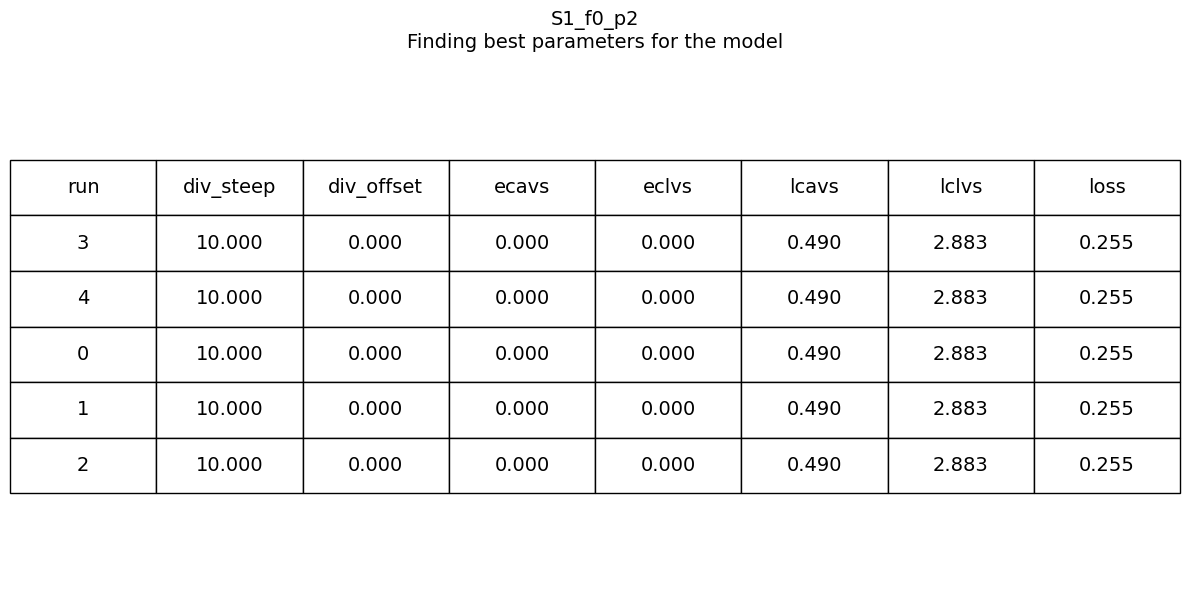

--------------------
f0/S1_f0_p2_runs_curves_1.png


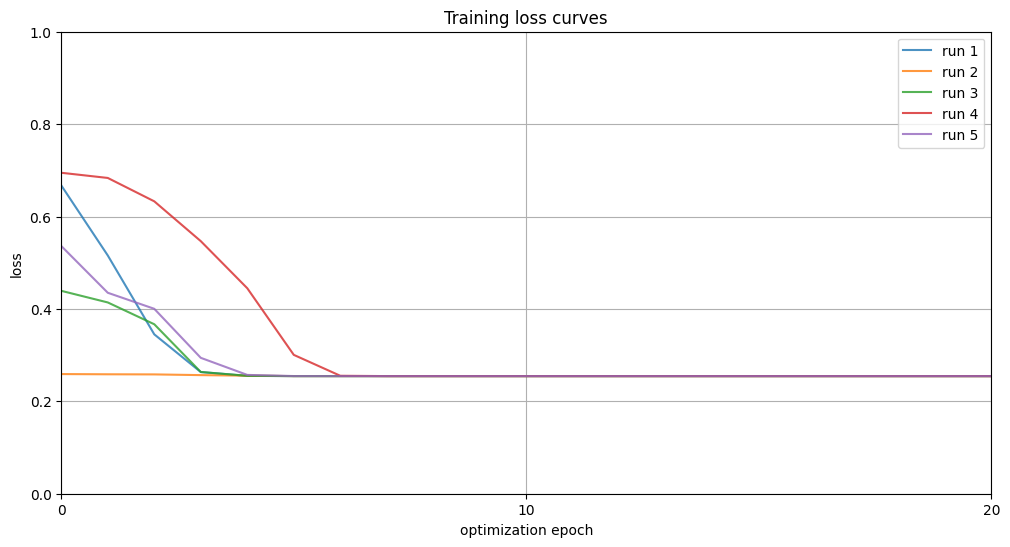

--------------------
f0/S1_f0_p2_runs_curves_2.png


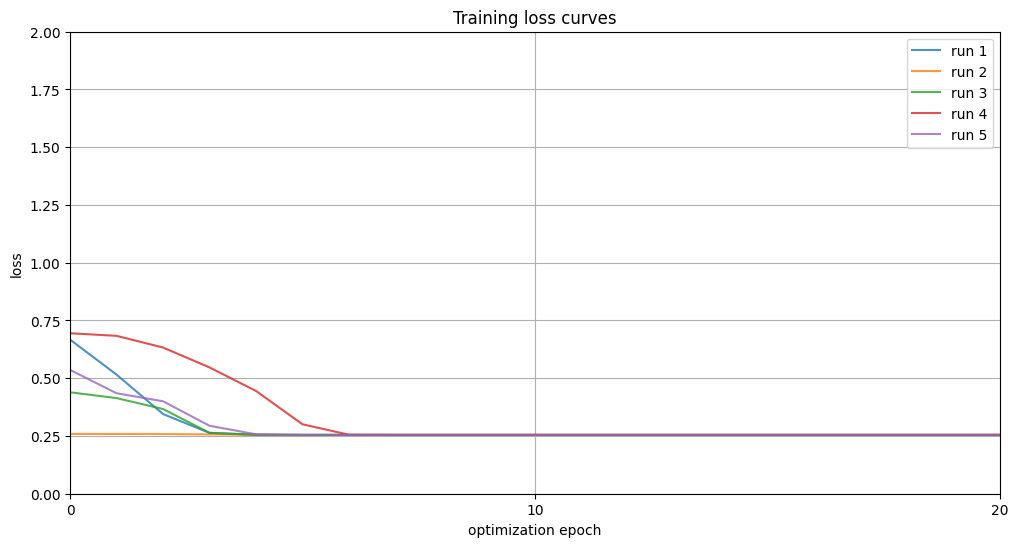

[1.00000000e+01 0.00000000e+00 1.50350329e-12 4.03898895e-11
 4.90250754e-01 2.88305801e+00]
0.25459187558740515
--------------------
f0/S1_f0_p2_div_curve.png


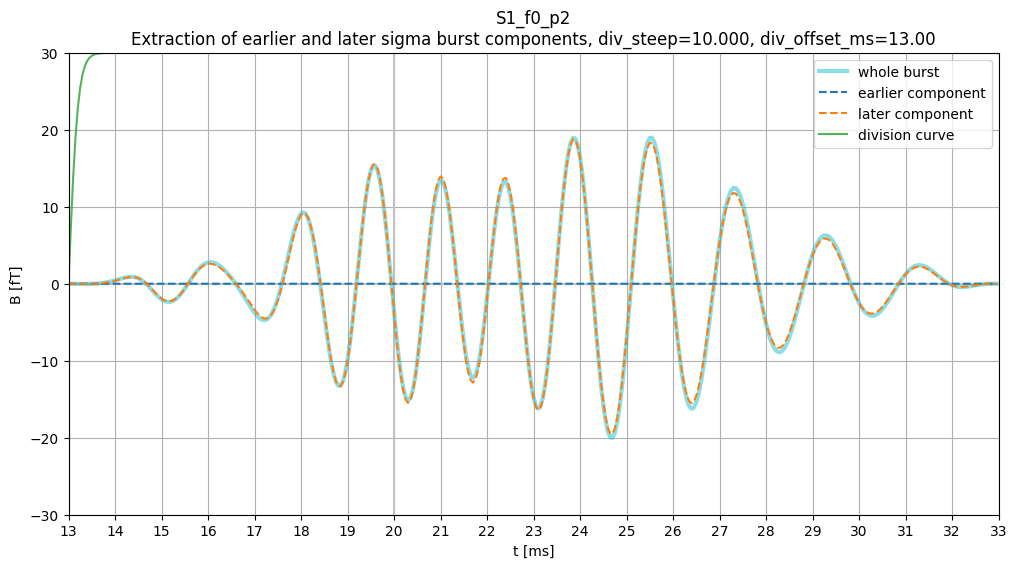

--------------------
f0/S1_f0_p2_train_set_loss.png


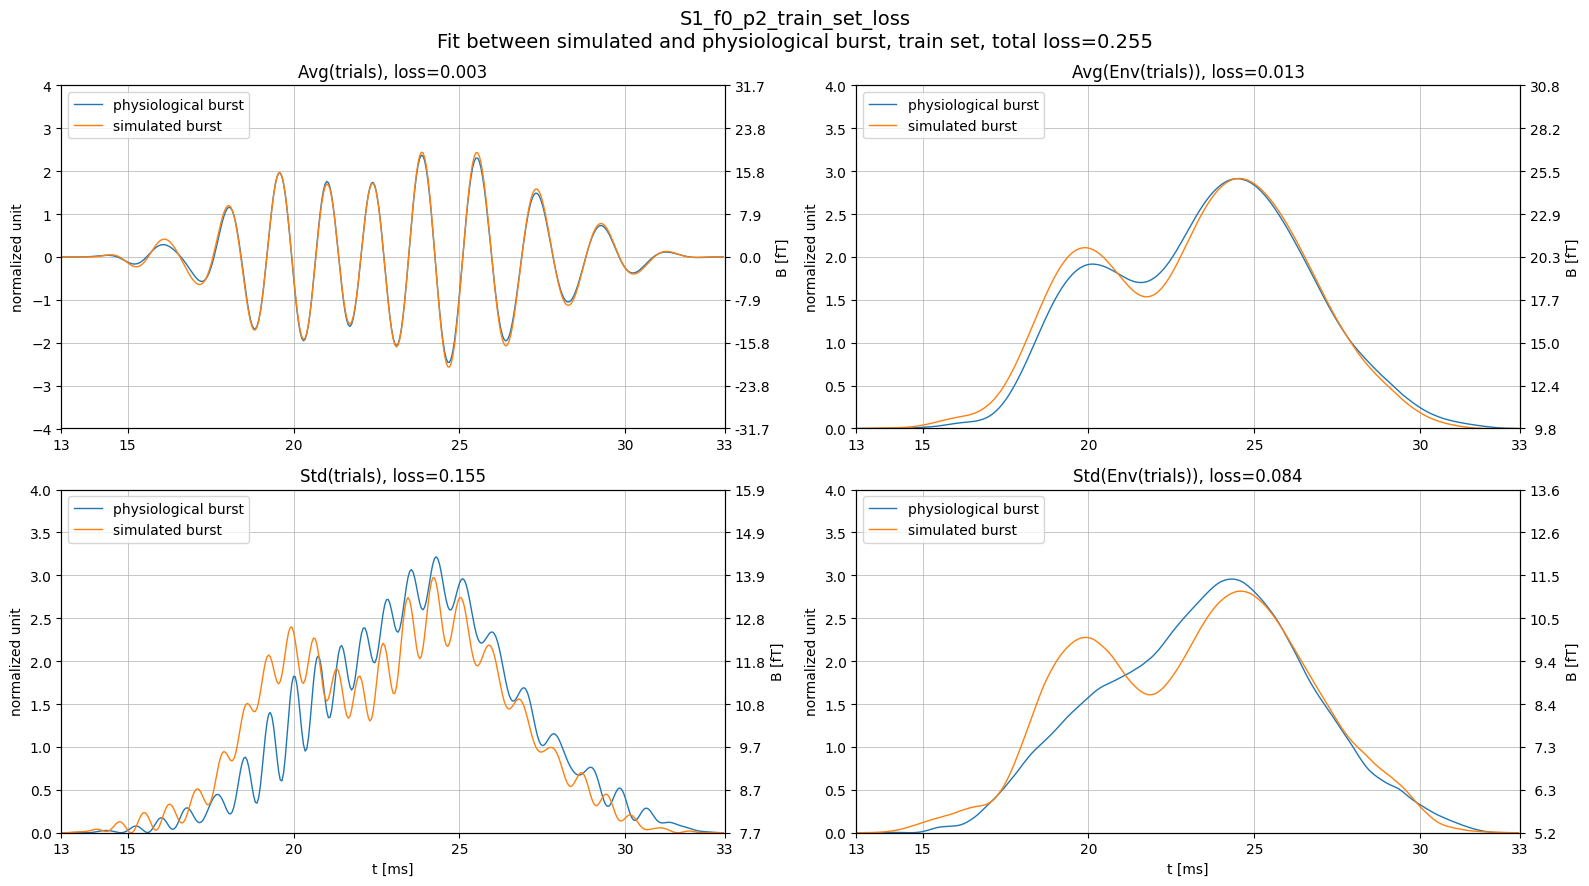

--------------------
f0/S1_f0_p2_test_set_loss.png


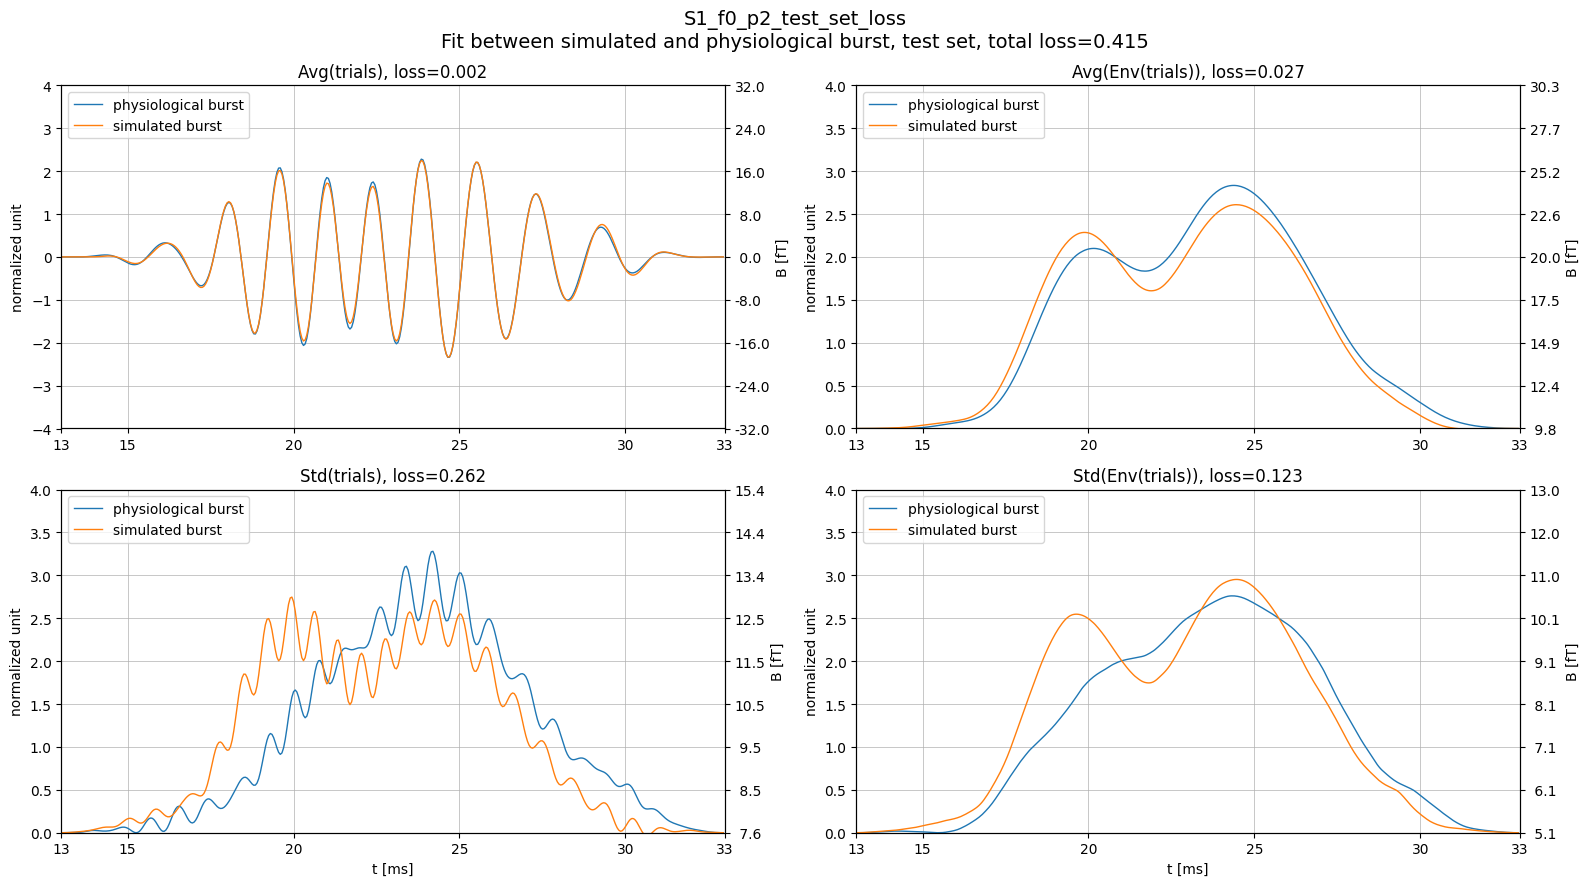

0.4145169975789008
run: 0, iter : 0
 fun: 0.30350330070448545
   x: [ 6.395e+00  1.547e-01  1.000e-10  3.783e-11  5.138e-01  2.427e+00]
run: 0, iter : 1
 fun: 0.2964331555526314
   x: [ 6.395e+00  1.537e-01  1.000e-10  4.190e-11  5.364e-01  2.445e+00]
run: 0, iter : 2
 fun: 0.2939847604275313
   x: [ 6.395e+00  1.533e-01  1.000e-10  1.000e-10  5.370e-01  2.460e+00]
run: 0, iter : 3
 fun: 0.2599706355786493
   x: [ 6.395e+00  1.482e-01  1.000e-10  1.000e-10  5.201e-01  2.808e+00]
run: 0, iter : 4
 fun: 0.25441093070305243
   x: [ 6.396e+00  1.520e-01  1.000e-10  1.000e-10  5.009e-01  2.864e+00]
run: 0, iter : 5
 fun: 0.2534839150611007
   x: [ 6.396e+00  1.557e-01  1.000e-10  1.000e-10  4.902e-01  2.880e+00]
run: 0, iter : 6
 fun: 0.25346580629462484
   x: [ 6.396e+00  1.570e-01  1.000e-10  1.000e-10  4.899e-01  2.882e+00]
run: 0, iter : 7
 fun: 0.2533299552235185
   x: [ 6.395e+00  1.714e-01  1.000e-10  1.000e-10  4.881e-01  2.889e+00]
run: 0, iter : 8
 fun: 0.15923321299087603
   x: [

KeyboardInterrupt: 

In [16]:
for fold in range(10):

    rndm_seed=fold//2

    np.random.seed(rndm_seed)
    n_trials = sigma_medium_trials.shape[-1]
    set_A_samples = np.random.choice(n_trials, size=n_trials//2, replace=False)
    set_A_samples.sort()
    set_B_samples = np.setdiff1d(np.arange(n_trials), set_A_samples)


    if(fold % 2 == 0):
        sigma_medium_trials_train = sigma_medium_trials[:,set_A_samples]
        sigma_medium_trials_test = sigma_medium_trials[:,set_B_samples]
    else:
        sigma_medium_trials_train = sigma_medium_trials[:,set_B_samples]
        sigma_medium_trials_test = sigma_medium_trials[:,set_A_samples]

    if(n_trials < 1200):
        #train_set_aug_samples = np.random.choice(n_trials//2, n_trials//2, replace=True)
        sigma_medium_trials_train = np.concatenate([sigma_medium_trials_train,
                                                    sigma_medium_trials_train], axis=1)
        sigma_medium_trials_test = np.concatenate([sigma_medium_trials_test,
                                                    sigma_medium_trials_test], axis=1)


    os.makedirs(os.path.join(plots_output_folder, 'f'+str(fold)+'/'), exist_ok=True)

    for m_cmplx in range(4):

        fig_title_base = subject+'_f'+str(fold)+'_p'+str(m_cmplx*2)
        fig_name_base = 'f'+str(fold)+'/'+fig_title_base

        bm_train = BurstModel(data_t_medium_ms, sigma_medium_trials_train,
                            burst_win_ms, sigma_sim_offset_ms, srate, rndm_seed+100)

        bm_test = BurstModel(data_t_medium_ms, sigma_medium_trials_test,
                            burst_win_ms, sigma_sim_offset_ms, srate, rndm_seed+200)

        eps=1e-10

        if(m_cmplx == 0):
            # no variability
            model_variables = (10, 0, 0, 0, 0, 0)

        else:

            if(m_cmplx == 1):
                # variable burst without split
                bnds = scipy.optimize.Bounds(lb=(10, 0, 0, 0, 0, 0), ub=(10+eps, eps, eps, eps, 2, 5))
                maxfun = 500
            elif(m_cmplx == 2):
                # split + later cmp variability
                bnds = scipy.optimize.Bounds(lb=(0.5, 0, 0, 0, 0, 0), ub=(10, 1, eps, eps, 2, 5))
                maxfun = 1000
            elif(m_cmplx == 3):
                # full variability model
                bnds = scipy.optimize.Bounds(lb=(0.5, 0, 0, 0, 0, 0), ub=(10, 1, 1, 3, 2, 5))
                maxfun = 2000


            runs_loss_curves = []
            runs_loss_temp = []
            runs_loss_fin = []
            runs_params_fin = []

            n_runs = 5 # number of performed runs
            opt_run = 0 # optimization run
            opt_iter = 0 # optimization iteration

            def opt_callback(intermediate_result):

                global opt_iter
                runs_loss_temp.append(intermediate_result['fun'])
                print('run: %d, iter : %d' % (opt_run, opt_iter))
                print(intermediate_result)
                opt_iter += 1

            for opt_run in range(n_runs):

                opt_iter = 0
                runs_loss_temp = []

                minimizer_kwargs = {'method':'L-BFGS-B', 'bounds':bnds, 'callback':opt_callback}
                opt_results = scipy.optimize.dual_annealing(lambda arg : bm_train.calculate_model_output(arg)[0],
                                                            bounds=bnds, maxfun=maxfun, minimizer_kwargs=minimizer_kwargs)

                runs_loss_curves.append(runs_loss_temp)
                runs_params_fin.append(opt_results.x)
                runs_loss_fin.append(opt_results.fun)

            max_epochs = np.max([len(k) for k in runs_loss_curves])
            max_epochs = np.ceil(max_epochs/20)*20
            max_epochs = int(max_epochs)


            # convert lists to arrays
            # if early stopping was applied
            # extend them to the length of max_epochs
            for i in range(len(runs_loss_curves)):
                arr = runs_loss_curves[i]
                arr = np.array(arr)
                arr = np.concatenate((arr, (np.ones(max_epochs+1-len(arr))*arr[-1])))
                runs_loss_curves[i] = arr

            runs_loss_curves = np.array(runs_loss_curves)
            runs_loss_fin = np.array(runs_loss_fin)
            runs_params_fin = np.array(runs_params_fin)


            # plot output as a table
            table_data = np.concatenate(([np.arange(len(runs_params_fin))], runs_params_fin.T, [runs_loss_fin])).T
            table_data = table_data[table_data[:, -1].argsort()]
            table_data = np.array([["{:.3f}".format(value) for value in row] for row in table_data])
            for i in range(len(table_data[:,0])): table_data[:,0][i] = table_data[:,0][i].split('.')[0]
            table_labels = ['run', 'div_steep', 'div_offset', 'ecavs', 'eclvs', 'lcavs', 'lclvs', 'loss']

            fig, ax = plt.subplots()
            plt.suptitle(fig_title_base+'\nFinding best parameters for the model', fontsize=14)
            table = ax.table(cellText=table_data, colLabels=table_labels, loc='center', cellLoc='center')
            table.set_fontsize(15)
            table.scale(1, 3)
            ax.axis('off')
            fig.tight_layout()
            plt_show_save_fig(fig_name_base+'_runs_table')

            # plot training curves
            fig, ax = plt.subplots()
            plt.title('Training loss curves', fontsize=12)
            y_max=1
            ax.plot(runs_loss_curves.T, alpha=0.8)
            ax.set_xlim(0, max_epochs)
            ax.set_ylim(0.0, y_max)
            ax.set_xlabel('optimization epoch')
            ax.set_ylabel('loss')
            ax.xaxis.set_major_locator(plticker.MultipleLocator(10))
            ax.yaxis.set_major_locator(plticker.MultipleLocator(0.2))
            ax.grid(visible=True)
            ax.legend([f"run {i+1}" for i in range(len(runs_loss_curves))])
            plt_show_save_fig(fig_name_base+'_runs_curves_1')

            # plot training curves
            fig, ax = plt.subplots()
            plt.title('Training loss curves', fontsize=12)
            y_max=2
            ax.plot(runs_loss_curves.T, alpha=0.8)
            ax.set_xlim(0, max_epochs)
            ax.set_ylim(0.0, y_max)
            ax.set_xlabel('optimization epoch')
            ax.set_ylabel('loss')
            ax.xaxis.set_major_locator(plticker.MultipleLocator(10))
            ax.yaxis.set_major_locator(plticker.MultipleLocator(0.25))
            ax.grid(visible=True)
            ax.legend([f"run {i+1}" for i in range(len(runs_loss_curves))])
            plt_show_save_fig(fig_name_base+'_runs_curves_2')

            # take parameters from the best run
            model_variables = runs_params_fin[runs_loss_fin.argmin()]

        [div_steep, div_offset, ecavs, eclvs, lcavs, lclvs] = model_variables
        div_offset_ms = div_offset*(burst_win_ms[1]-burst_win_ms[0])+burst_win_ms[0]

        [result, division_curve, later_comp_sigma_er, lcabs, earlier_comp_sigma_er, ecabs, sigma_bursts_sim,
        sigma_sim_medium_trials] = [i.numpy() for i in bm_train.calculate_model_output(model_variables)]

        train_loss = result
        print(model_variables)
        print(train_loss)

        # plot extracted components
        fig, ax = plt.subplots()
        plt.title(fig_title_base+'\nExtraction of earlier and later sigma burst components, ' \
        'div_steep=%.3f, div_offset_ms=%.2f' % (div_steep, div_offset_ms), fontsize=12)

        ax.axhline(0, color='silver')
        ax.axvline(20, color='silver')
        ax.plot(data_t_burst_ms, sigma_bursts_sim.real.mean(-1), label='whole burst', linewidth=3, alpha=0.5, c='tab:cyan')
        ax.plot(data_t_burst_ms, earlier_comp_sigma_er.real, label='earlier component', linestyle='--')
        ax.plot(data_t_burst_ms, later_comp_sigma_er.real, label='later component', linestyle='--')
        division_curve_rescaled = 30*(2*division_curve-1)
        ax.plot(data_t_medium_ms, division_curve_rescaled, alpha=0.8, label='division curve')

        ax.set_xlabel('t [ms]')
        ax.set_ylabel(meg_unit)
        vmax=30
        ax.set_ylim((-vmax,vmax))
        ax.set_xlim((burst_win_ms[0], burst_win_ms[-1]))
        ax.xaxis.set_major_locator(plticker.MultipleLocator(1))
        ax.grid(visible=True)
        ax.legend()

        plt_show_save_fig(fig_name_base+'_div_curve')

        plot_loss_results(bm_train, sigma_sim_medium_trials,
                        filename=fig_name_base+'_train_set_loss')

        [result, division_curve, later_comp_sigma_er, lcabs, earlier_comp_sigma_er, ecabs, sigma_bursts_sim,
        sigma_sim_medium_trials] = [i.numpy() for i in bm_test.calculate_model_output(model_variables)]


        plot_loss_results(bm_test, sigma_sim_medium_trials, is_test_set=True,
                        filename=fig_name_base+'_test_set_loss')

        test_loss = result
        print(test_loss)

        new_out_record = [subject, fold, m_cmplx*2, div_steep, div_offset,
                        ecavs, eclvs, lcavs, lclvs, train_loss, test_loss]
        df_out.loc[len(df_out)] = new_out_record

In [ ]:
df_out

In [ ]:
df_out.to_csv(os.path.join(plots_output_folder, subject+'_results.csv'), index=False)